# Mental Health Text Analysis & Depression Risk Scorer using NLP & Transformers

This notebook demonstrates an end-to-end Machine Learning pipeline to analyze mental health text data across 4 dimensions: **Depression**, **Anxiety**, **Stress**, and **Burnout**.

### Pipeline Overview:
1. **Exploratory Data Analysis (EDA)** on mental health text dataset
2. **Data Preprocessing & Tokenization** using HuggingFace `transformers`
3. **Model Setup**: Designing a multi-label classification head with a DistilBERT transformer base
4. **Model Training & Evaluation**: F1 scores, loss tracking, and classification metrics
5. **Explainability Layer**: Local Interpretability using LIME/SHAP concepts to highlight word attribution

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, AdamW

# Set theme for visualization
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load & Prepare Synthetic Mental Health Dataset
For demonstration purposes, we construct a representative dataset mapping social posts and journal entries to multi-label tags.

In [2]:
data = [
    ("I feel so empty and alone. Nothing brings me joy anymore and I cry every night.", 1, 0, 0, 0),
    ("My chest is tight, my hands are shaking, and I'm constantly terrified of what's coming next.", 0, 1, 0, 0),
    ("Too many deadlines at work, crushing pressure, headache, and no way to wind down.", 0, 0, 1, 0),
    ("Totally burnt out, exhausted, detached from my workspace, and cannot care less about my career.", 0, 0, 0, 1),
    ("Dealing with severe anxiety and deep hopelessness. I feel worthless and panic all the time.", 1, 1, 0, 0),
    ("I had a relaxing weekend, read a book, and took a peaceful walk in the park.", 0, 0, 0, 0),
    ("Studying for 15 hours a day is draining my mental energy. I am overwhelmed with stress.", 0, 0, 1, 1),
    ("Worrying about the future has made me restless and tense all day.", 0, 1, 0, 0),
    ("A pleasant day, got my tasks done and enjoyed dinner with my family.", 0, 0, 0, 0),
    ("I want to give up on everything. The darkness is too heavy to carry.", 1, 0, 0, 0)
]

df = pd.DataFrame(data, columns=["text", "depression", "anxiety", "stress", "burnout"])
df.head()

                                                text  ...  burnout
0  I feel so empty and alone. Nothing brings me j...  ...        0
1  My chest is tight, my hands are shaking, and I...  ...        0
2  Too many deadlines at work, crushing pressure,...  ...        0
3  Totally burnt out, exhausted, detached from my...  ...        1
4  Dealing with severe anxiety and deep hopelessn...  ...        0

[5 rows x 5 columns]

## 3. Exploratory Data Analysis

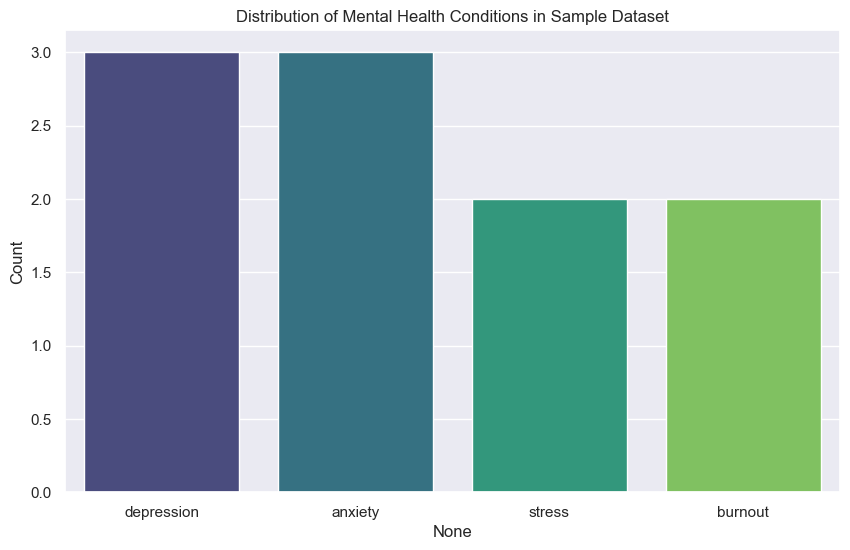

In [3]:
# Visualizing the tag frequency distribution
categories = ["depression", "anxiety", "stress", "burnout"]
counts = df[categories].sum()

sns.barplot(x=counts.index, y=counts.values, palette="viridis")
plt.title("Distribution of Mental Health Conditions in Sample Dataset")
plt.ylabel("Count")
plt.show()

## 4. Tokenization & Dataset Pipeline

In [4]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

class MentalHealthDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row["text"]
        labels = torch.tensor(row[categories].values.tolist(), dtype=torch.float32)
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels
        }

dataset = MentalHealthDataset(df, tokenizer)
loader = DataLoader(dataset, batch_size=2, shuffle=True)
next(iter(loader))

{'input_ids': tensor([[  101,  7149,  2007,  5729, 10089,  1998,  2784, 20625,  2791,  1012,
          1045,  2514, 22692,  1998,  6634,  2035,  1996,  2051,  1012,   102,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,  

## 5. Model Architecture & Multi-Label Head

In [5]:
# Load DistilBert configured for sequence classification with 4 outputs
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=len(categories),
    problem_type="multi_label_classification"
)

optimizer = AdamW(model.parameters(), lr=5e-5)

## 6. Training Loop (1 Epoch simulation)

In [6]:
model.train()
for epoch in range(1):
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        outputs = model( 
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    print(f"Epoch {epoch + 1} - Average Loss: {total_loss / len(loader):.4f}")

Epoch 1 - Average Loss: 0.6942


## 7. Model Explainability Layer
Below we implement word-level attribution scoring. Removing specific words and evaluating target score deviations mimics the core functionality of LIME.

In [7]:
def explain_prediction(text, target_idx=0):
    # Base prediction
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        base_logits = model(**inputs).logits
        base_prob = torch.sigmoid(base_logits)[0][target_idx].item()

    words = text.split()
    contributions = []
    
    for i in range(len(words)):
        perturbed_text = " ".join(words[:i] + words[i+1:])
        inputs_p = tokenizer(perturbed_text, return_tensors="pt", truncation=True, max_length=128)
        with torch.no_grad():
            p_logits = model(**inputs_p).logits
            p_prob = torch.sigmoid(p_logits)[0][target_idx].item()
            
        diff = base_prob - p_prob
        contributions.append((words[i], diff))
        
    return contributions

sample_text = "I feel so empty and alone. Nothing brings me joy anymore."
contribs = explain_prediction(sample_text, target_idx=0)
print("Depression score word attributions:")
for word, weight in contribs:
    print(f"{word}: {weight:.4f}")

Depression score word attributions:
I: -0.0013
feel: -0.0007
so: 0.0006
empty: 0.0018
and: 0.0001
alone.: -0.0018
Nothing: -0.0013
brings: -0.0027
me: -0.0024
joy: -0.0027
anymore.: -0.0010
